In [2]:
using JLD2, LaTeXStrings, PGFPlotsX, FileIO, Plots, ColorSchemes

# pgfplotsx()

In [59]:
log(1/3)

-1.0986122886681098

In [133]:
function theoretical_fidelity_limit(α)
    β = sqrt(1 - α^2)
    fidelity_limit = α^4 + β ^4
    return sqrt(fidelity_limit)
end

function single_particle_evolution_fidelity(α, γ_dephase, t=268)
    β = sqrt(1-α^2)
    fidelity = α^4 + β^4 + (2 * α^2 * β^2 *(exp(-γ_dephase*t)))
    return sqrt(fidelity)
end

single_particle_evolution_fidelity (generic function with 2 methods)

In [134]:
theoretical_fidelity_limit(sqrt(1/5))

0.824621125123532

In [135]:
single_particle_evolution_fidelity(sqrt(1/5),1e-4)

0.9957599603504715

### dephase = 1e-5

In [136]:
y1

0.9977319822693812

[2, 2, 2, 2]

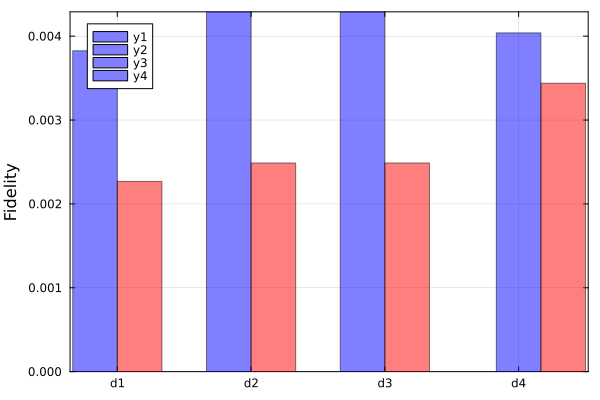

In [15]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=1.0e-5_case1_Nphase=10_avg.jld2"
y1 = final_fidelity_after_correction
x1= final_fidelity_after_encoding
fidelity_limit1 = theoretical_fidelity_limit(sqrt(1/5))

@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=1.0e-5_case2_Nphase=10_avg.jld2"
y2 = final_fidelity_after_correction
x2 = final_fidelity_after_encoding

@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=1.0e-5_case2_Nphase=10_avg.jld2"
y3 = final_fidelity_after_correction
x3 = final_fidelity_after_encoding

@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=1.0e-5_case4_Nphase=10_avg.jld2"
y4 = final_fidelity_after_correction
x4 = final_fidelity_after_encoding


labels = ["Without Correction Protocol", "With Correction Protocol"]

d1, d2, d3, d4 = [1-x1,1-y1], [1-x2,1-y2], [1-x3, 1-y3], [1-x4,1-y4]
dlist = [d1, d2, d3, d4]
ni = length.(dlist)
print(ni)
dc = distinguishable_colors(maximum(ni), [RGB(0,0,0),RGB(1,1,1)], dropseed=true)
plot(ylabel="Fidelity", widen=false)
# k = 1
# for (n,d) in zip(ni, dlist)
#     print(n,d)
#     bar!(1:n, d, bar_width=1, c=dc[1:n])
# end

bar!(1:2, d1, bar_width=1, c=[:blue, :red], alpha=[0.5,0.5])
# plot!([0.5:1.5],[1-fidelity_limit1,1-fidelity_limit1], color = :red, label = "Fidelity Limit", linewidth=2, linestyle=:dash)
bar!(4:5, d2, bar_width=1, c=[:blue, :red], alpha=[0.5,0.5])
bar!(7:8, d3, bar_width=1, c=[:blue, :red], alpha=[0.5,0.5])
bar!(10:12, d4, bar_width=1, c=[:blue, :red], alpha=[0.5,0.5])
xticks!(cumsum(ni .+ 1) .- (ni .+ 1)/2, ["d1","d2","d3","d4"])

Fidelity limit: 0.824621125123532
Fidelity after encoding: 0.9961740685589886
Fidelity after correction: 0.9977319822693812


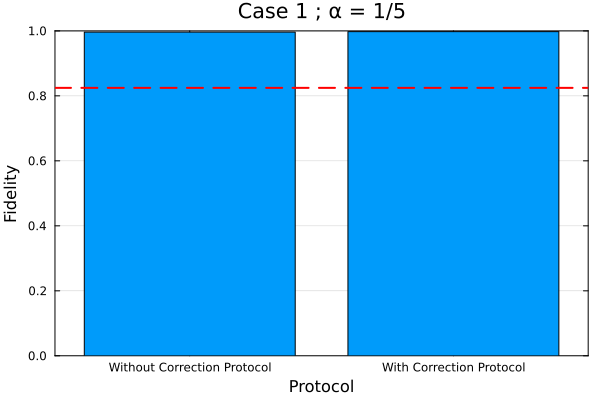

In [91]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=1.0e-5_case1_Nphase=10_avg.jld2"

fidelity_after_correction = final_fidelity_after_correction
fidelity_after_encoding = final_fidelity_after_encoding

y1 = fidelity_after_correction
x1 = fidelity_after_encoding

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [fidelity_after_encoding, fidelity_after_correction]

fidelity_limit1 = theoretical_fidelity_limit(sqrt(1/5))
println("Fidelity limit: ", fidelity_limit1)
println("Fidelity after encoding: ", fidelity_after_encoding)
println("Fidelity after correction: ", fidelity_after_correction)

bar(x, y, 
    title = "Case 1 ; α = 1/5",
    xlabel = "Protocol",
    ylabel = "Fidelity",
    legend = false,
    ylim = [0,1]
)
hline!([fidelity_limit1], color = :red, label = "Fidelity Limit", linewidth=2, linestyle=:dash)

Fidelity limit: 0.7211102550927979
Fidelity after encoding: 0.9957095826061009
Fidelity after correction: 0.9975121755540022


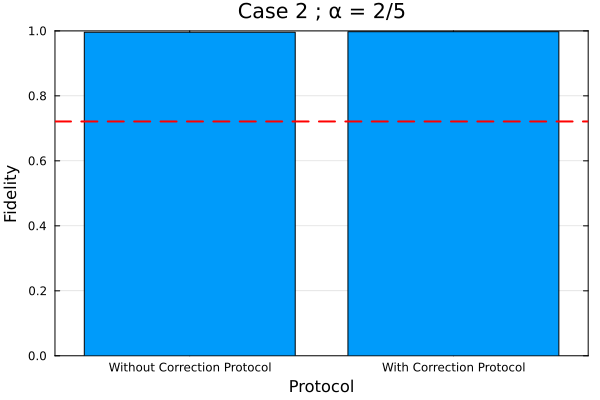

In [92]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=1.0e-5_case2_Nphase=10_avg.jld2"

fidelity_after_correction = final_fidelity_after_correction
fidelity_after_encoding = final_fidelity_after_encoding

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [fidelity_after_encoding, fidelity_after_correction]
y2 = fidelity_after_correction
x2 = fidelity_after_encoding

fidelity_limit2 = theoretical_fidelity_limit(sqrt(2/5))
println("Fidelity limit: ", fidelity_limit2)

println("Fidelity after encoding: ", fidelity_after_encoding)
println("Fidelity after correction: ", fidelity_after_correction)

bar(x, y, 
    title = "Case 2 ; α = 2/5",
    xlabel = "Protocol",
    ylabel = "Fidelity",
    legend = false,
    ylim = [0,1]
)
hline!([fidelity_limit2], color = :red, label = "Fidelity Limit", linewidth=2, linestyle=:dash)

Fidelity limit: 0.7211102550927978
Fidelity after encoding: 0.9956377512936027
Fidelity after correction: 0.9972404173769255


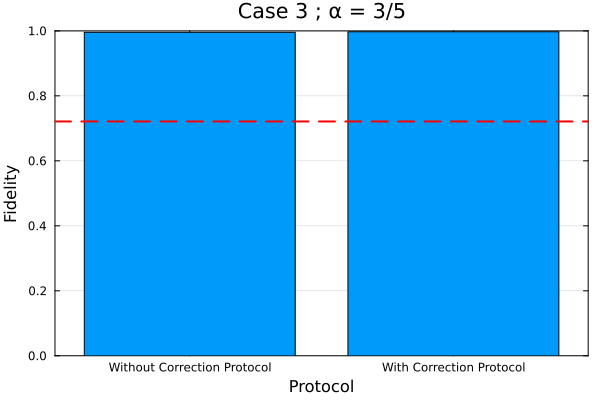

In [93]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=1.0e-5_case3_Nphase=10_avg.jld2"

fidelity_after_correction = final_fidelity_after_correction
fidelity_after_encoding = final_fidelity_after_encoding

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [fidelity_after_encoding, fidelity_after_correction]
y3 = fidelity_after_correction
x3 = fidelity_after_encoding

fidelity_limit3 = theoretical_fidelity_limit(sqrt(3/5))
println("Fidelity limit: ", fidelity_limit3)

println("Fidelity after encoding: ", fidelity_after_encoding)
println("Fidelity after correction: ", fidelity_after_correction)

bar(x, y, 
    title = "Case 3 ; α = 3/5",
    xlabel = "Protocol",
    ylabel = "Fidelity",
    legend = false,
    ylim = [0,1]
)
hline!([fidelity_limit3], color = :red, label = "Fidelity Limit", linewidth=2, linestyle=:dash)

Fidelity limit: 0.824621125123532
Fidelity after encoding: 0.9959608464802779
Fidelity after correction: 0.9965615468214853


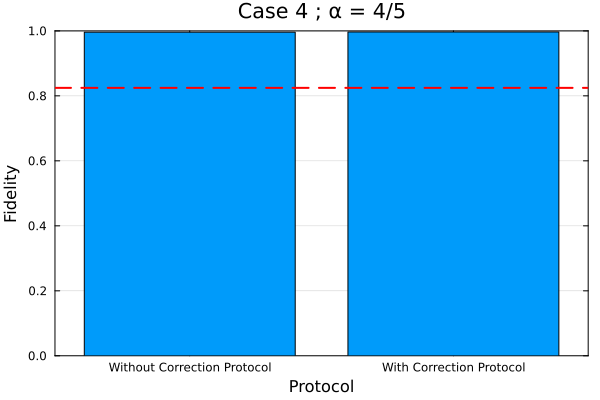

In [94]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=1.0e-5_case4_Nphase=10_avg.jld2"

fidelity_after_correction = final_fidelity_after_correction
fidelity_after_encoding = final_fidelity_after_encoding

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [fidelity_after_encoding, fidelity_after_correction]

y4 = fidelity_after_correction
x4 = fidelity_after_encoding
fidelity_limit = theoretical_fidelity_limit(sqrt(4/5))
println("Fidelity limit: ", fidelity_limit)

println("Fidelity after encoding: ", fidelity_after_encoding)
println("Fidelity after correction: ", fidelity_after_correction)

bar(x, y, 
    title = "Case 4 ; α = 4/5",
    xlabel = "Protocol",
    ylabel = "Fidelity",
    legend = false,
    ylim = [0,1]
)
hline!([fidelity_limit], color = :red, label = "Fidelity Limit", linewidth=2, linestyle=:dash)

In [95]:
# using PyPlot                       # thin Julia wrapper
# fig = figure()
# ax = fig.add_subplot(111, projection="3d")

# α      = [1/5, 2/5, 3/5, 4/5]
# before = [x1, x2, x3, x4]
# after  = [y1, y2, y3, y4]

# xpos = repeat(α, inner=2)          # 0.1,0.1,0.25,0.25,…
# ypos = repeat([0,1], outer=length(α)) # 0=before 1=after
# zpos = zeros(length(xpos))

# dx, dy = 0.05, 0.8
# dz      = vcat(before, after)

# ax.bar3d(xpos, ypos, zpos, dx, dy, dz, shade=true)
# ax.set_xticks(α);         ax.set_xlabel("α")
# ax.set_yticks([0.4,1.4]); ax.set_yticklabels(["before","after"])
# ax.set_zlabel("value")
# ax.set_title("3‑D bars (Matplotlib backend)")
# display(fig)

### dephase = 1e-4

Fidelity after encoding: 0.9806262912434974
Fidelity after correction: 0.9908999250608451
Theoretical fidelity limit: 0.824621125123532


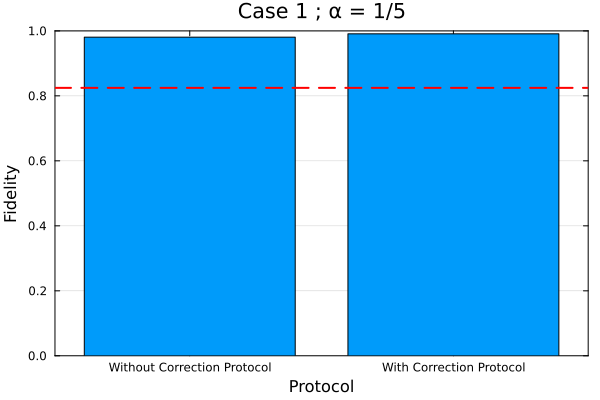

In [96]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=0.0001_case1_Nphase=10_avg.jld2"

fidelity_after_correction = final_fidelity_after_correction
fidelity_after_encoding = final_fidelity_after_encoding

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [fidelity_after_encoding, fidelity_after_correction]
fidelity_limit = theoretical_fidelity_limit(sqrt(1/5))


println("Fidelity after encoding: ", fidelity_after_encoding)
println("Fidelity after correction: ", fidelity_after_correction)
println("Theoretical fidelity limit: ", fidelity_limit)

bar(x, y, 
    title = "Case 1 ; α = 1/5",
    xlabel = "Protocol",
    ylabel = "Fidelity",
    legend = false,
    ylim = [0,1]
)
hline!([fidelity_limit], color = :red, label = "Fidelity Limit", linewidth=2, linestyle=:dash)

Fidelity after encoding: 0.9778121917121739
Fidelity after correction: 0.9912531152236135
Theoretical fidelity limit: 0.7211102550927979


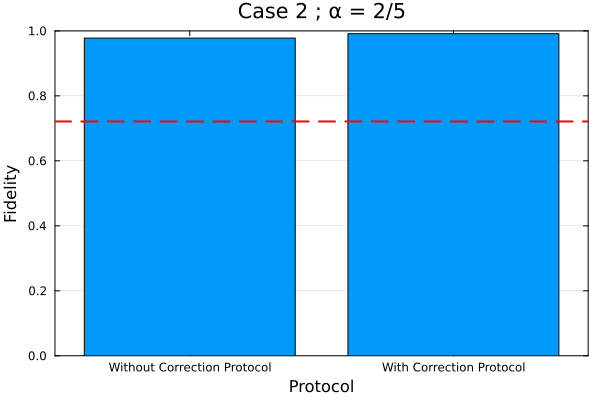

In [97]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=0.0001_case2_Nphase=10_avg.jld2"

fidelity_after_correction = final_fidelity_after_correction
fidelity_after_encoding = final_fidelity_after_encoding

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [fidelity_after_encoding, fidelity_after_correction]
fidelity_limit = theoretical_fidelity_limit(sqrt(2/5))


println("Fidelity after encoding: ", fidelity_after_encoding)
println("Fidelity after correction: ", fidelity_after_correction)
println("Theoretical fidelity limit: ", fidelity_limit)

bar(x, y, 
    title = "Case 2 ; α = 2/5",
    xlabel = "Protocol",
    ylabel = "Fidelity",
    legend = false,
    ylim = [0,1]
)
hline!([fidelity_limit], color = :red, label = "Fidelity Limit", linewidth=2, linestyle=:dash)

Fidelity after encoding: 0.9778105406599127
Fidelity after correction: 0.9905966070478517
Theoretical fidelity limit: 0.7211102550927978


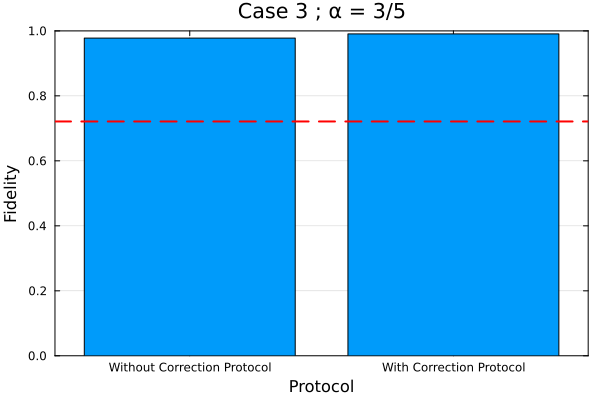

In [98]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=0.0001_case3_Nphase=10_avg.jld2"

fidelity_after_correction = final_fidelity_after_correction
fidelity_after_encoding = final_fidelity_after_encoding

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [fidelity_after_encoding, fidelity_after_correction]
fidelity_limit = theoretical_fidelity_limit(sqrt(3/5))


println("Fidelity after encoding: ", fidelity_after_encoding)
println("Fidelity after correction: ", fidelity_after_correction)
println("Theoretical fidelity limit: ", fidelity_limit)

bar(x, y, 
    title = "Case 3 ; α = 3/5",
    xlabel = "Protocol",
    ylabel = "Fidelity",
    legend = false,
    ylim = [0,1]
)
hline!([fidelity_limit], color = :red, label = "Fidelity Limit", linewidth=2, linestyle=:dash)

Fidelity after encoding: 0.9806385475405733
Fidelity after correction: 0.9908103022033607
Theoretical fidelity limit: 0.824621125123532


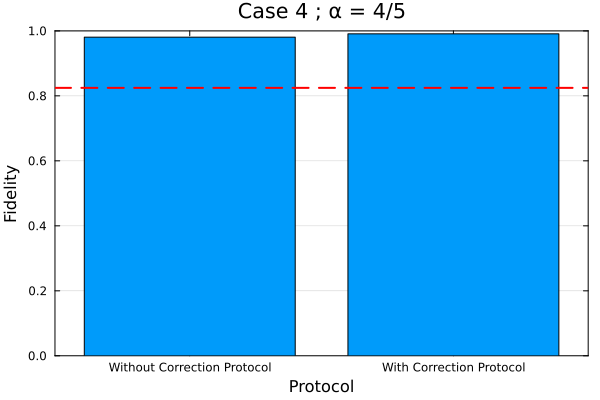

In [99]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=0.0001_case4_Nphase=10_avg.jld2"

fidelity_after_correction = final_fidelity_after_correction
fidelity_after_encoding = final_fidelity_after_encoding

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [fidelity_after_encoding, fidelity_after_correction]
fidelity_limit = theoretical_fidelity_limit(sqrt(4/5))


println("Fidelity after encoding: ", fidelity_after_encoding)
println("Fidelity after correction: ", fidelity_after_correction)
println("Theoretical fidelity limit: ", fidelity_limit)

bar(x, y, 
    title = "Case 4 ; α = 4/5",
    xlabel = "Protocol",
    ylabel = "Fidelity",
    legend = false,
    ylim = [0,1]
)
hline!([fidelity_limit], color = :red, label = "Fidelity Limit", linewidth=2, linestyle=:dash)

### dephase = 1e-3

Fidelity after encoding: 0.8410239110976652
Fidelity after correction: 0.9269639572940858
Theoretical fidelity limit: 0.824621125123532


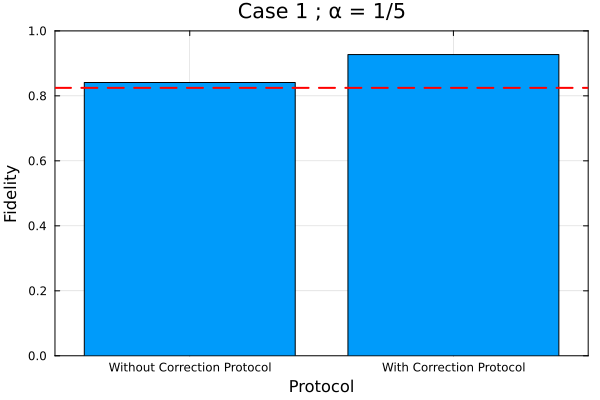

In [100]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=0.001_case1_Nphase=10_avg.jld2"

fidelity_after_correction = final_fidelity_after_correction
fidelity_after_encoding = final_fidelity_after_encoding

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [fidelity_after_encoding, fidelity_after_correction]
fidelity_limit = theoretical_fidelity_limit(sqrt(1/5))


println("Fidelity after encoding: ", fidelity_after_encoding)
println("Fidelity after correction: ", fidelity_after_correction)
println("Theoretical fidelity limit: ", fidelity_limit)

bar(x, y, 
    title = "Case 1 ; α = 1/5",
    xlabel = "Protocol",
    ylabel = "Fidelity",
    legend = false,
    ylim = [0,1]
)
hline!([fidelity_limit], color = :red, label = "Fidelity Limit", linewidth=2, linestyle=:dash)

Fidelity after encoding: 0.8128016551495579
Fidelity after correction: 0.9294178282175287
Theoretical fidelity limit: 0.7211102550927979


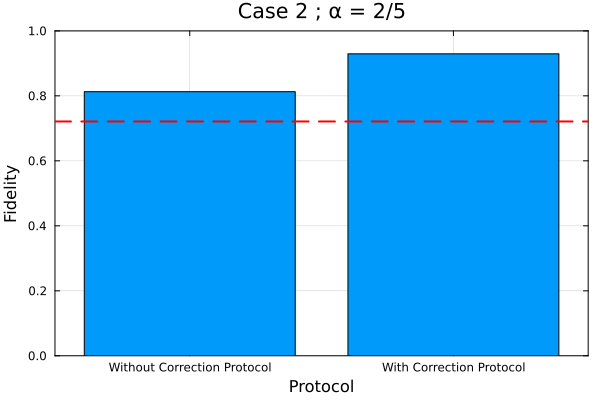

In [101]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=0.001_case2_Nphase=10_avg.jld2"

fidelity_after_correction = final_fidelity_after_correction
fidelity_after_encoding = final_fidelity_after_encoding

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [fidelity_after_encoding, fidelity_after_correction]
fidelity_limit = theoretical_fidelity_limit(sqrt(2/5))


println("Fidelity after encoding: ", fidelity_after_encoding)
println("Fidelity after correction: ", fidelity_after_correction)
println("Theoretical fidelity limit: ", fidelity_limit)

bar(x, y, 
    title = "Case 2 ; α = 2/5",
    xlabel = "Protocol",
    ylabel = "Fidelity",
    legend = false,
    ylim = [0,1]
)
hline!([fidelity_limit], color = :red, label = "Fidelity Limit", linewidth=2, linestyle=:dash)

Fidelity after encoding: 0.8115180223786942
Fidelity after correction: 0.9314520924135051
Theoretical fidelity limit: 0.7211102550927978


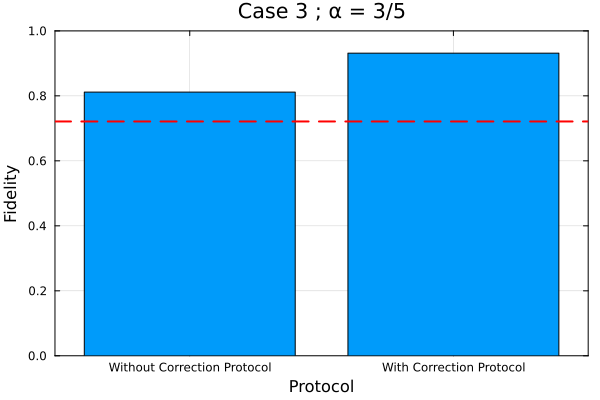

In [102]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=0.001_case3_Nphase=10_avg.jld2"

fidelity_after_correction = final_fidelity_after_correction
fidelity_after_encoding = final_fidelity_after_encoding

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [fidelity_after_encoding, fidelity_after_correction]
fidelity_limit = theoretical_fidelity_limit(sqrt(3/5))


println("Fidelity after encoding: ", fidelity_after_encoding)
println("Fidelity after correction: ", fidelity_after_correction)
println("Theoretical fidelity limit: ", fidelity_limit)

bar(x, y, 
    title = "Case 3 ; α = 3/5",
    xlabel = "Protocol",
    ylabel = "Fidelity",
    legend = false,
    ylim = [0,1]
)
hline!([fidelity_limit], color = :red, label = "Fidelity Limit", linewidth=2, linestyle=:dash)

Fidelity after encoding: 0.8378176170199594
Fidelity after correction: 0.9248290189668906
Theoretical fidelity limit: 0.824621125123532


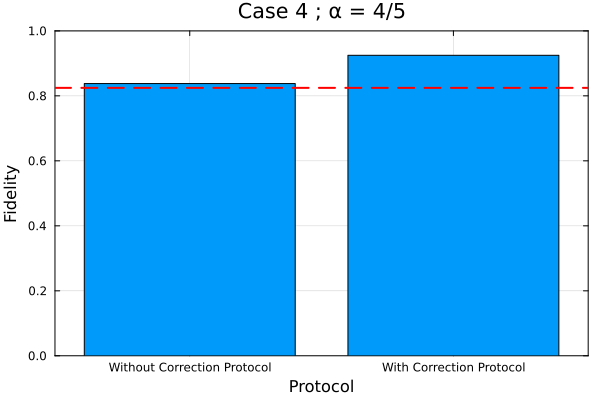

In [103]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=0.001_case4_Nphase=10_avg.jld2"

fidelity_after_correction = final_fidelity_after_correction
fidelity_after_encoding = final_fidelity_after_encoding

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [fidelity_after_encoding, fidelity_after_correction]
fidelity_limit = theoretical_fidelity_limit(sqrt(4/5))


println("Fidelity after encoding: ", fidelity_after_encoding)
println("Fidelity after correction: ", fidelity_after_correction)
println("Theoretical fidelity limit: ", fidelity_limit)

bar(x, y, 
    title = "Case 4 ; α = 4/5",
    xlabel = "Protocol",
    ylabel = "Fidelity",
    legend = false,
    ylim = [0,1]
)
hline!([fidelity_limit], color = :red, label = "Fidelity Limit", linewidth=2, linestyle=:dash)

### dephase = 0.01

Fidelity after encoding: 0.3270165652324869
Fidelity after correction: 0.6314901965668155
Theoretical fidelity limit: 0.824621125123532


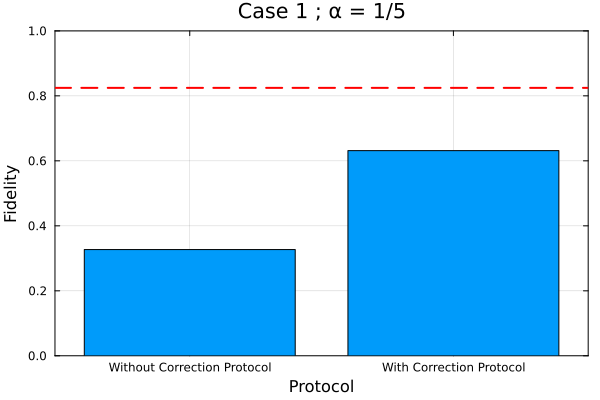

In [104]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=0.01_case1_Nphase=10_avg.jld2"

fidelity_after_correction = final_fidelity_after_correction
fidelity_after_encoding = final_fidelity_after_encoding

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [fidelity_after_encoding, fidelity_after_correction]
fidelity_limit = theoretical_fidelity_limit(sqrt(1/5))


println("Fidelity after encoding: ", fidelity_after_encoding)
println("Fidelity after correction: ", fidelity_after_correction)
println("Theoretical fidelity limit: ", fidelity_limit)

bar(x, y, 
    title = "Case 1 ; α = 1/5",
    xlabel = "Protocol",
    ylabel = "Fidelity",
    legend = false,
    ylim = [0,1]
)
hline!([fidelity_limit], color = :red, label = "Fidelity Limit", linewidth=2, linestyle=:dash)

Fidelity after encoding: 0.27072239161966927
Fidelity after correction: 0.6630535153572019
Theoretical fidelity limit: 0.7211102550927979


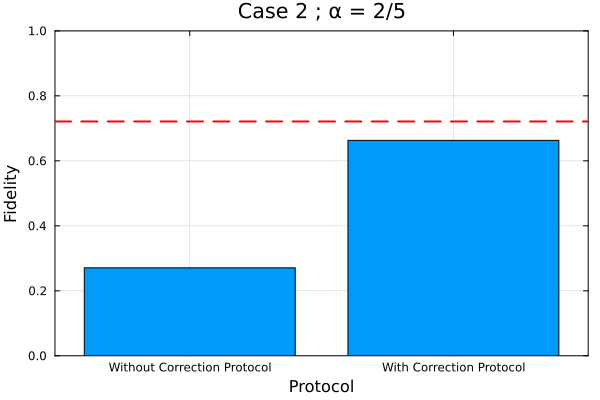

In [105]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=0.01_case2_Nphase=10_avg.jld2"

fidelity_after_correction = final_fidelity_after_correction
fidelity_after_encoding = final_fidelity_after_encoding

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [fidelity_after_encoding, fidelity_after_correction]
fidelity_limit = theoretical_fidelity_limit(sqrt(2/5))


println("Fidelity after encoding: ", fidelity_after_encoding)
println("Fidelity after correction: ", fidelity_after_correction)
println("Theoretical fidelity limit: ", fidelity_limit)

bar(x, y, 
    title = "Case 2 ; α = 2/5",
    xlabel = "Protocol",
    ylabel = "Fidelity",
    legend = false,
    ylim = [0,1]
)
hline!([fidelity_limit], color = :red, label = "Fidelity Limit", linewidth=2, linestyle=:dash)

Fidelity after encoding: 0.26569100748872154
Fidelity after correction: 0.6564585871191406
Theoretical fidelity limit: 0.7211102550927978


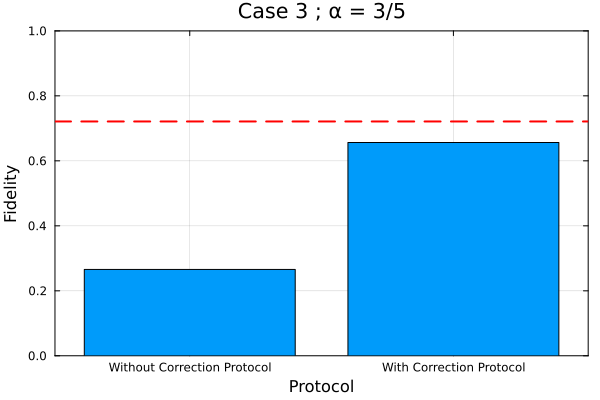

In [106]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=0.01_case3_Nphase=10_avg.jld2"

fidelity_after_correction = final_fidelity_after_correction
fidelity_after_encoding = final_fidelity_after_encoding

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [fidelity_after_encoding, fidelity_after_correction]
fidelity_limit = theoretical_fidelity_limit(sqrt(3/5))


println("Fidelity after encoding: ", fidelity_after_encoding)
println("Fidelity after correction: ", fidelity_after_correction)
println("Theoretical fidelity limit: ", fidelity_limit)

bar(x, y, 
    title = "Case 3 ; α = 3/5",
    xlabel = "Protocol",
    ylabel = "Fidelity",
    legend = false,
    ylim = [0,1]
)
hline!([fidelity_limit], color = :red, label = "Fidelity Limit", linewidth=2, linestyle=:dash)

Fidelity after encoding: 0.3270165652324869
Fidelity after correction: 0.6314901965668155
Theoretical fidelity limit: 0.824621125123532


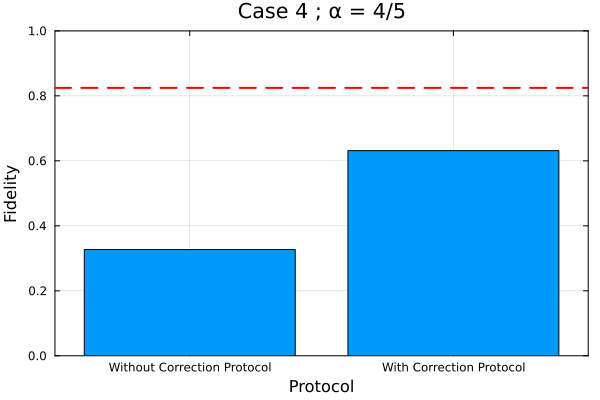

In [107]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=0.01_case1_Nphase=10_avg.jld2"

fidelity_after_correction = final_fidelity_after_correction
fidelity_after_encoding = final_fidelity_after_encoding

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [fidelity_after_encoding, fidelity_after_correction]
fidelity_limit = theoretical_fidelity_limit(sqrt(4/5))


println("Fidelity after encoding: ", fidelity_after_encoding)
println("Fidelity after correction: ", fidelity_after_correction)
println("Theoretical fidelity limit: ", fidelity_limit)

bar(x, y, 
    title = "Case 4 ; α = 4/5",
    xlabel = "Protocol",
    ylabel = "Fidelity",
    legend = false,
    ylim = [0,1]
)
hline!([fidelity_limit], color = :red, label = "Fidelity Limit", linewidth=2, linestyle=:dash)

### dephase = 0.1

Fidelity after encoding: 0.13456668029418623
Fidelity after correction: 0.41111829373498776
Theoretical fidelity limit: 0.824621125123532


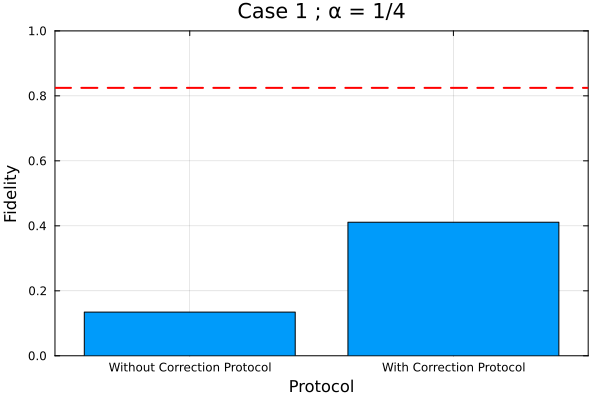

In [108]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=0.1_case1_Nphase=10_avg.jld2"

fidelity_after_correction = final_fidelity_after_correction
fidelity_after_encoding = final_fidelity_after_encoding

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [fidelity_after_encoding, fidelity_after_correction]
fidelity_limit = theoretical_fidelity_limit(sqrt(1/5))


println("Fidelity after encoding: ", fidelity_after_encoding)
println("Fidelity after correction: ", fidelity_after_correction)
println("Theoretical fidelity limit: ", fidelity_limit)

bar(x, y, 
    title = "Case 1 ; α = 1/4",
    xlabel = "Protocol",
    ylabel = "Fidelity",
    legend = false,
    ylim = [0,1]
)
hline!([fidelity_limit], color = :red, label = "Fidelity Limit", linewidth=2, linestyle=:dash)

Fidelity after encoding: 0.12483080196038608
Fidelity after correction: 0.4009955920188068
Theoretical fidelity limit: 0.7211102550927979


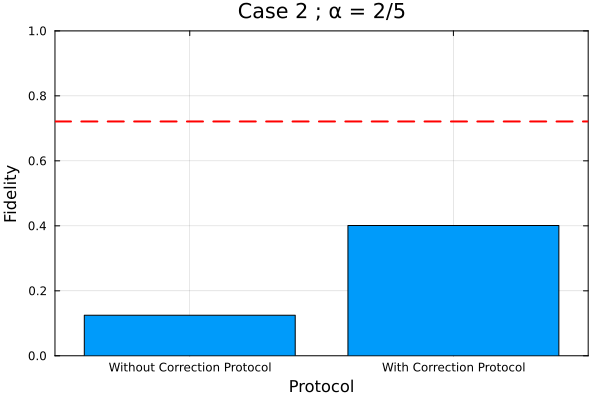

In [109]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=0.1_case2_Nphase=10_avg.jld2"

fidelity_after_correction = final_fidelity_after_correction
fidelity_after_encoding = final_fidelity_after_encoding

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [fidelity_after_encoding, fidelity_after_correction]
fidelity_limit = theoretical_fidelity_limit(sqrt(2/5))


println("Fidelity after encoding: ", fidelity_after_encoding)
println("Fidelity after correction: ", fidelity_after_correction)
println("Theoretical fidelity limit: ", fidelity_limit)

bar(x, y, 
    title = "Case 2 ; α = 2/5",
    xlabel = "Protocol",
    ylabel = "Fidelity",
    legend = false,
    ylim = [0,1]
)
hline!([fidelity_limit], color = :red, label = "Fidelity Limit", linewidth=2, linestyle=:dash)

Fidelity after encoding: 0.12251815968778955
Fidelity after correction: 0.38444568529258993
Theoretical fidelity limit: 0.7211102550927978


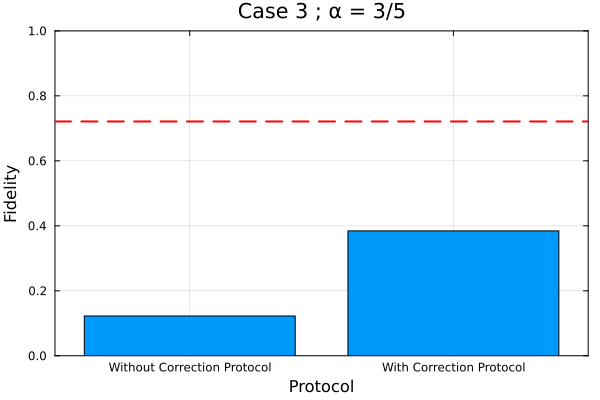

In [110]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=0.1_case3_Nphase=10_avg.jld2"

fidelity_after_correction = final_fidelity_after_correction
fidelity_after_encoding = final_fidelity_after_encoding

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [fidelity_after_encoding, fidelity_after_correction]
fidelity_limit = theoretical_fidelity_limit(sqrt(3/5))


println("Fidelity after encoding: ", fidelity_after_encoding)
println("Fidelity after correction: ", fidelity_after_correction)
println("Theoretical fidelity limit: ", fidelity_limit)

bar(x, y, 
    title = "Case 3 ; α = 3/5",
    xlabel = "Protocol",
    ylabel = "Fidelity",
    legend = false,
    ylim = [0,1]
)
hline!([fidelity_limit], color = :red, label = "Fidelity Limit", linewidth=2, linestyle=:dash)

Fidelity after encoding: 0.13055868416506056
Fidelity after correction: 0.361327663167504
Theoretical fidelity limit: 0.824621125123532


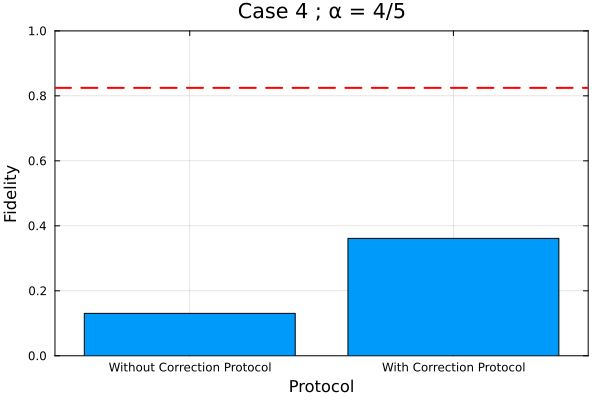

In [111]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/double_avg_files/N_atoms=5_γ_dephase=0.1_case4_Nphase=10_avg.jld2"

fidelity_after_correction = final_fidelity_after_correction
fidelity_after_encoding = final_fidelity_after_encoding

x = ["Without Correction Protocol", "With Correction Protocol"]
y = [fidelity_after_encoding, fidelity_after_correction]
fidelity_limit = theoretical_fidelity_limit(sqrt(4/5))


println("Fidelity after encoding: ", fidelity_after_encoding)
println("Fidelity after correction: ", fidelity_after_correction)
println("Theoretical fidelity limit: ", fidelity_limit)

bar(x, y, 
    title = "Case 4 ; α = 4/5",
    xlabel = "Protocol",
    ylabel = "Fidelity",
    legend = false,
    ylim = [0,1]
)
hline!([fidelity_limit], color = :red, label = "Fidelity Limit", linewidth=2, linestyle=:dash)